# ISO 20414:2020 — Test 1: Pre-evacuation time assignment

8 m x 5 m room, 1 m exit, 10 occupants (ISO 20414:2020 Table 2). Impose pre-defined pre-evacuation distributions (uniform, normal, log-normal) and verify each occupant starts moving within the specified range. Repeated over multiple runs per ISO.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 07 July 2026, 18:25 CEST


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from jupedsim_scenarios import load_scenario, run_scenario

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

In [4]:
from scenario_builders.iso01_premovement import build_variants, sample_reference

## Load the base scenario

In [5]:
SCENARIO_ZIP = Path("scenario_files") / "Iso-01-premovement.zip"
base = load_scenario(str(SCENARIO_ZIP))
print(base.summary())

Scenario: /Users/chraibi/workspace/PedestrianDynamics/jupedsim-web-community/standards/iso/scenario_files/Iso-01-premovement.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      2400s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      1
  Agents:        ~10
  Journey elems: 2
  Route:         1 distribution, 0 checkpoint, 1 exit
  Sequence:      jps-distributions_0 -> jps-exits_0
    jps-distributions_0: 10 agents


## Sweep the ISO distributions over multiple runs

`build_variants` deep-copies the base scenario, overrides `premovement_*` directly on the distribution's parameters, and sets `max_simulation_time` for the distribution tail. ISO Test 1 requires the assignment to be verified over multiple runs, so each distribution is run with `N_RUNS` seeds and the per-occupant start times are pooled across runs.

In [6]:
N_RUNS = 10  # ISO Test 1: repeat each distribution over multiple runs
SEEDS = [42 + i for i in range(N_RUNS)]
runs = {}
for seed in SEEDS:
    for case, variant in build_variants(base):
        result = run_scenario(variant, seed=seed)
        df = result.trajectory_dataframe()
        for agent_id, sub in df.sort_values(['id', 'frame']).groupby('id'):
            x0, y0 = sub.iloc[0][['x', 'y']]
            moved = sub[(sub.x - x0).abs() + (sub.y - y0).abs() > 0.05]
            t = (moved.iloc[0]['frame'] / result.frame_rate) if len(moved) else float('nan')
            runs.setdefault(case.name, {'case': case, 'observed_starts': []})['observed_starts'].append(t)
        result.cleanup()
for name in runs:
    runs[name]['observed_starts'] = np.array(runs[name]['observed_starts'])

## Observed vs analytic pre-evacuation times

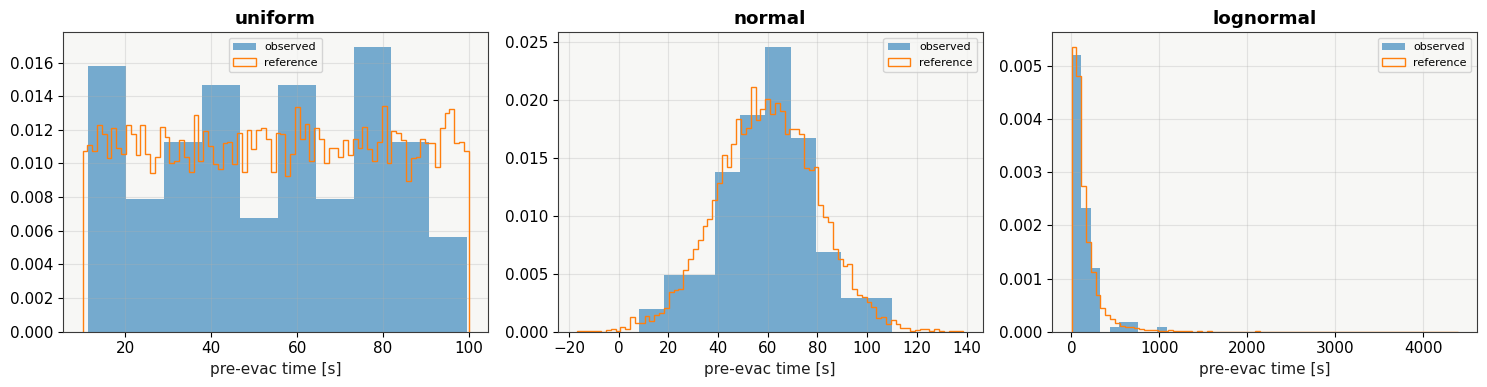

In [7]:
fig, axes = plt.subplots(1, len(runs), figsize=(5 * len(runs), 4))
axes = np.atleast_1d(axes)
for ax, (name, run) in zip(axes, runs.items()):
    obs = run['observed_starts']
    obs = obs[~np.isnan(obs)]
    if len(obs):
        ax.hist(obs, bins=10, density=True, alpha=0.6, label='observed')
    ref = sample_reference(run['case'], 10000, seed=1)
    ax.hist(ref, bins=80, density=True, histtype='step', label='reference')
    ax.set_title(name); ax.set_xlabel('pre-evac time [s]'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## Acceptance

Each occupant must start within the distribution's support, and observed starts should be consistent with the assigned family (two-sample KS, alpha = 0.05).

In [8]:
from scipy import stats as _stats
ALPHA = 0.05
rows = []
for name, run in runs.items():
    obs = run['observed_starts']
    obs = obs[~np.isnan(obs)]
    ref = sample_reference(run['case'], 10000, seed=2)
    ks = _stats.ks_2samp(obs, ref) if len(obs) else None
    rows.append({'case': name, 'n': int(len(obs)),
                 'min_s': float(obs.min()) if len(obs) else float('nan'),
                 'max_s': float(obs.max()) if len(obs) else float('nan'),
                 'ks_p': ks.pvalue if ks else float('nan')})
fit = pd.DataFrame(rows)
print(fit)
assert (fit['ks_p'] > ALPHA).all(), fit

        case    n  min_s   max_s      ks_p
0    uniform  100   11.2    99.7  0.743841
1     normal  100    8.2   109.8  0.970137
2  lognormal  100    8.1  1083.9  0.962192
